# XGBoost (Extreme Gradient Boosting)

---

## What is XGBoost?
- XGBoost is a **machine learning algorithm** based on the principle of **gradient boosting**.
- It builds an **ensemble of decision trees**, not just one tree.
- Each tree is trained **sequentially**, correcting the errors of the previous ones.
- Known for **speed, accuracy, and efficiency**, especially on structured/tabular datasets.

---

## How Sequential Boosting Works
1. **First Tree** → makes initial predictions, but leaves residual errors.  
2. **Second Tree** → trained on those residuals, focusing on correcting mistakes.  
3. **Third Tree** → further reduces errors left after combining Tree 1 + Tree 2.  
4. **Final Prediction** = sum of all trees, each scaled by the learning rate (η).  

Mathematically:


\[
Final\ Prediction = \sum_{t=1}^{n} \eta \cdot Tree_t(x)
\]



Think of it like a relay race: each runner (tree) picks up where the last left off, correcting mistakes step by step.

---

## Key Parameters and Their Role
- **eta (learning_rate)**  
  - Controls how much each tree contributes to the final prediction.  
  - Small η → slower learning, but more accurate and less overfitting.  
  - Large η → faster learning, but risk of overshooting and overfitting.  

- **n_estimators**  
  - Number of trees in the ensemble.  
  - More trees = better correction of errors, but longer training time.  

- **max_depth**  
  - Maximum depth of each tree.  
  - Shallow trees (low depth) → weak learners, but combine well in boosting.  
  - Deep trees → risk of overfitting.  

- **subsample**  
  - Fraction of training samples used per tree.  
  - Adds randomness, prevents overfitting.  


---

## Advantages
- High accuracy on structured/tabular data.  
- Handles missing values automatically.  
- Fast training due to parallelization.  
- Widely used in Kaggle competitions and industry applications.  

---

## Key Insight
- XGBoost = **gradient boosting with extra power**.  
- It uses decision trees as base learners, adds smart parameters like `eta`, and trains sequentially to correct errors.  
- Sequential error correction + parameter tuning = strong, reliable model that often outperforms single decision trees or parallel methods like Random Forest.

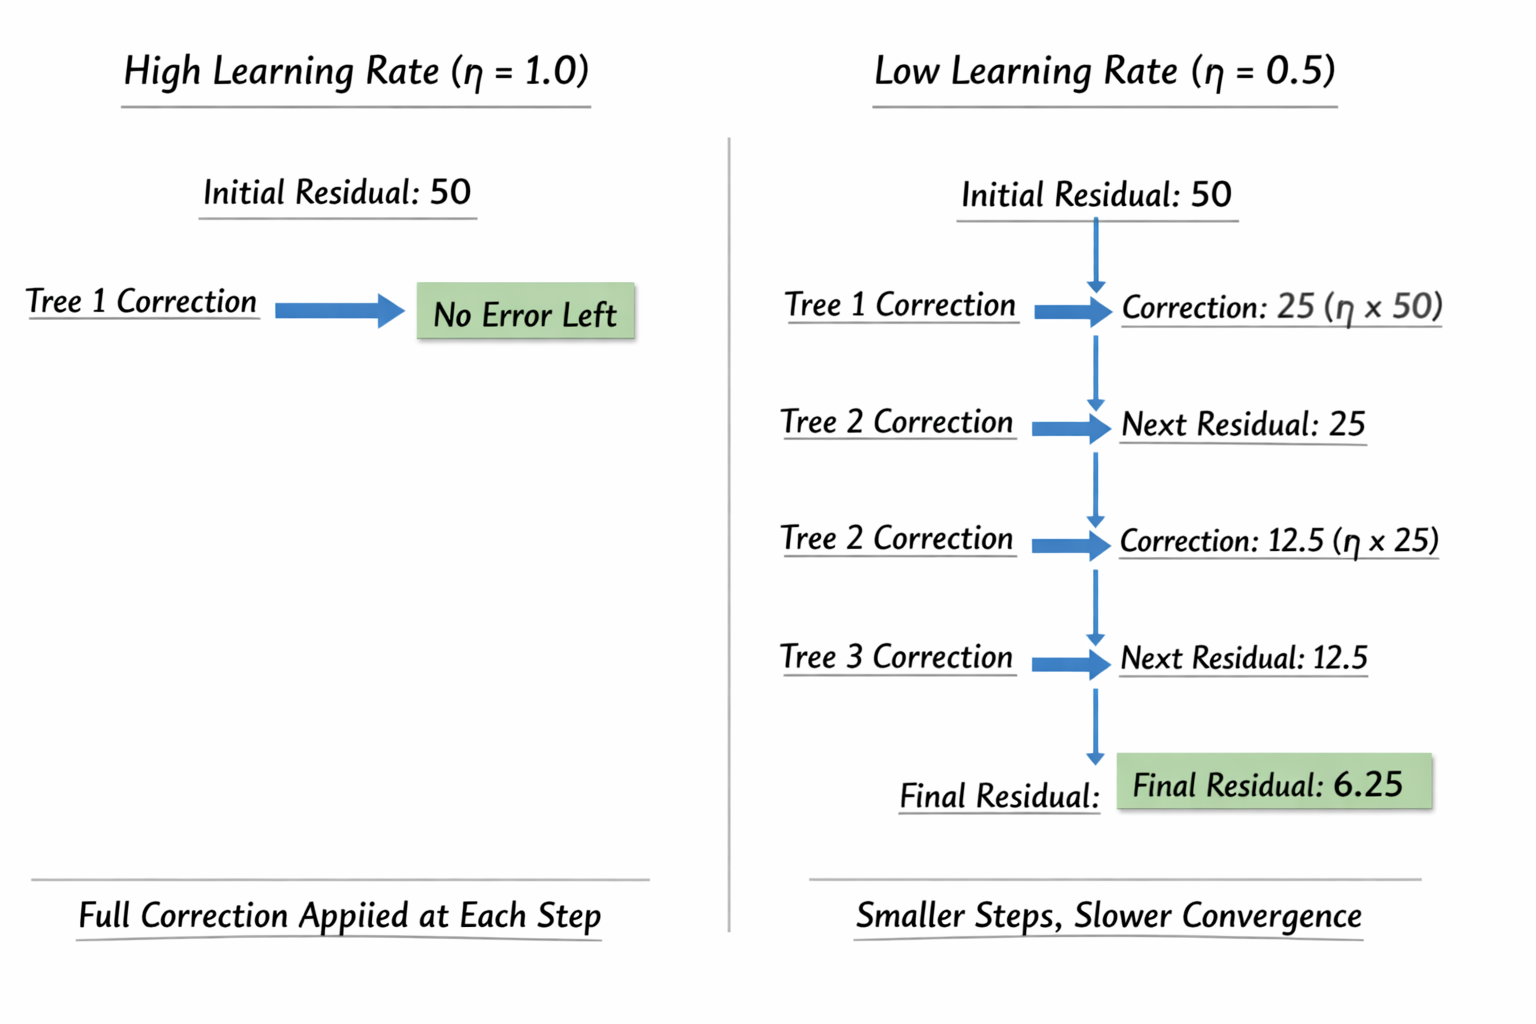

In [10]:
from IPython.display import Image

# Load and display the image
Image(filename='/Users/pradipwasre/Machine-Learning/notebooks/part10_model_selection_boosting/eta.png')

In [9]:
# --------------------------------------------
# Step 1: Importing essential libraries
# --------------------------------------------

# NumPy → for numerical operations, arrays, and matrix handling
import numpy as np

# Matplotlib → for plotting graphs and visualizing clusters
import matplotlib.pyplot as plt

# Pandas → for handling datasets, tables, and dataframes
import pandas as pd

In [2]:
# --------------------------------------------
# Step 2: Importing the dataset
# --------------------------------------------

# Load the dataset from CSV file
dataset = pd.read_csv('Data.csv')

# Extract independent variables (features)
# iloc[:, :-1] → selects all rows, all columns except the last one
X = dataset.iloc[:, :-1].values

# Extract dependent variable (target/label)
# iloc[:, -1] → selects all rows, only the last column
y = dataset.iloc[:, -1].values

# Quick check: print shapes to confirm
print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)

Feature matrix shape: (683, 10)
Target vector shape: (683,)


In [3]:
# --------------------------------------------
# Step 3: Splitting the dataset into Training and Test sets
# --------------------------------------------

# Import the train_test_split function
from sklearn.model_selection import train_test_split

# Split the dataset into training and test sets
# Parameters:
# - X → feature matrix
# - y → target vector
# - test_size = 0.2 → 20% of data goes to test set, 80% to training set
# - random_state = 0 → ensures reproducibility (same split every run)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0
)

# Quick check: print shapes to confirm split
print("Training set shape:", X_train.shape, y_train.shape)
print("Test set shape:", X_test.shape, y_test.shape)


Training set shape: (546, 10) (546,)
Test set shape: (137, 10) (137,)


In [6]:
# --------------------------------------------
# Step 5: Fixing target labels for XGBoost
# --------------------------------------------

# Map the target labels: 2 → 0 (benign), 4 → 1 (malignant)
y_train_fixed = np.where(y_train == 2, 0, 1)
y_test_fixed  = np.where(y_test == 2, 0, 1)

# Initialize the classifier
from xgboost import XGBClassifier
classifier = XGBClassifier()

# Fit the classifier on the training set
classifier.fit(X_train, y_train_fixed)

XGBClassifier(base_score=0.5, booster='gbtree', callbacks=None,
              colsample_bylevel=1, colsample_bynode=1, colsample_bytree=1,
              early_stopping_rounds=None, enable_categorical=False,
              eval_metric=None, gamma=0, gpu_id=-1, grow_policy='depthwise',
              importance_type=None, interaction_constraints='',
              learning_rate=0.300000012, max_bin=256, max_cat_to_onehot=4,
              max_delta_step=0, max_depth=6, max_leaves=0, min_child_weight=1,
              missing=nan, monotone_constraints='()', n_estimators=100,
              n_jobs=0, num_parallel_tree=1, predictor='auto', random_state=0,
              reg_alpha=0, reg_lambda=1, ...)

In [7]:
# --------------------------------------------
# Step 6: Making Predictions and Evaluating
# --------------------------------------------

from sklearn.metrics import confusion_matrix, accuracy_score

# IMPORTANT: Fix the test labels (map 2→0, 4→1)
y_test_fixed = np.where(y_test == 2, 0, 1)

# Confusion matrix → shows counts of correct/incorrect predictions
cm = confusion_matrix(y_test_fixed, y_pred)
print("Confusion Matrix:\n", cm)

# Accuracy score → overall percentage of correct predictions
acc = accuracy_score(y_test_fixed, y_pred)
print("Accuracy:", acc)

Confusion Matrix:
 [[85  2]
 [ 1 49]]
Accuracy: 0.9781021897810219


## Model Evaluation Results

---

### Confusion Matrix
The confusion matrix shows how well the classifier predicted each class:

[[85  2]

[ 1 49]]



- **Row 1 (Actual Class = 0 → Benign)**  
  - 85 → correctly predicted as benign (True Negatives)  
  - 2 → misclassified as malignant (False Positives)  

- **Row 2 (Actual Class = 1 → Malignant)**  
  - 1 → misclassified as benign (False Negatives)  
  - 49 → correctly predicted as malignant (True Positives)  

---

#### Accuracy : 0.9781021897810219


This means the model correctly classified about **97.8% of the samples** in the test set.

---

### Interpretation
- The classifier is performing very well, with only **3 misclassifications** out of 137 test samples.  
- Most benign and malignant cases are correctly identified.  
- The small number of false positives and false negatives indicates strong reliability.  

---

### Key Insight
- **Confusion Matrix** helps us see *where* the model makes mistakes (benign vs malignant).  
- **Accuracy** gives the overall performance percentage.  
- Together, they provide a complete picture of model evaluation.

# k-Fold Cross Validation

---

## What is it?
- **k-Fold Cross Validation** is a model evaluation technique used to assess how well a machine learning model generalizes to unseen data.
- It splits the training dataset into **k equal parts (folds)**.
- The model is trained on **k−1 folds** and tested on the **remaining fold**, repeating this process **k times**.

---

## Where is it used?
- Used during **model selection and validation** to estimate performance.
- Helps detect **overfitting** or **underfitting**.
- Commonly applied in:
  - Classification and regression tasks
  - Hyperparameter tuning
  - Comparing different models

---

## How does it work?
1. Choose a value for **k** (commonly 5 or 10).
2. Split the training data into **k folds**.
3. For each fold:
   - Train the model on **k−1 folds**.
   - Test it on the **remaining fold**.
4. Collect the **accuracy (or other metric)** for each fold.
5. Compute:
   - **Mean accuracy** → overall performance.
   - **Standard deviation** → stability across folds.

---

## Example (10-Fold CV)

In [8]:
# --------------------------------------------
# Step 7: Applying k-Fold Cross Validation
# --------------------------------------------

from sklearn.model_selection import cross_val_score

# Perform 10-fold cross-validation on the training set
# IMPORTANT: use the fixed labels (y_train_fixed) if you mapped 2→0 and 4→1 earlier
accuracies = cross_val_score(estimator=classifier, X=X_train, y=y_train_fixed, cv=10)

# Print mean accuracy across folds
print("Accuracy: {:.2f} %".format(accuracies.mean() * 100))

# Print standard deviation (variation across folds)
print("Standard Deviation: {:.2f} %".format(accuracies.std() * 100))

Accuracy: 96.53 %
Standard Deviation: 2.63 %


In [15]:
# Optional: loop through each fold for clarity
for i, acc in enumerate(accuracies, start=1):
    print(f"Fold {i}: {acc*100:.2f} %")

Fold 1: 90.91 %
Fold 2: 96.36 %
Fold 3: 96.36 %
Fold 4: 98.18 %
Fold 5: 94.55 %
Fold 6: 100.00 %
Fold 7: 94.44 %
Fold 8: 96.30 %
Fold 9: 100.00 %
Fold 10: 98.15 %


## Cross-Validation Summary

---

### Results
- **Accuracy: 96.53 %** → strong average performance.  
- **Standard Deviation: 2.63 %** → low variation, meaning the model is stable across folds.  

---

### Interpretation
- The high accuracy shows the classifier is making correct predictions most of the time.  
- The low standard deviation indicates the performance is consistent across different folds of the dataset.  
- Together, this confirms your **XGBoost classifier is both accurate and reliable**.
